[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/Pesquisa-Operacional-III-A/blob/main/09_PNL.ipynb)

# Pesquisa Operacional III-A  


## Programação Não Linear (PNL)

**Professor:** Diogo Ferreira de Lima Silva  

# Preparação do ambiente

Se você estiver usando **Google Colab**, execute as células abaixo para instalar o `pyomo` e o solver `ipopt`.

> Em ambiente local, essas instalações podem não ser necessárias, desde que o Pyomo e o solver já estejam disponíveis.


In [2]:
# Instalação do Pyomo (execute no Google Colab, se necessário)
!pip -q install pyomo


In [3]:
# Instalação do IPOPT no Google Colab (execute se necessário)
!wget -N -q "https://matematica.unipv.it/gualandi/solvers/ipopt-linux64.zip"
!unzip -o -q ipopt-linux64


## 2. Importando bibliotecas


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pe
import sympy as sp

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Funções auxiliares

A célula abaixo cria pequenas funções para:
- resolver modelos no Pyomo;
- imprimir resultados de forma mais organizada.


In [5]:
def resolver_modelo(modelo, solver="ipopt", tee=False):
    opt = pe.SolverFactory(solver)
    resultado = opt.solve(modelo, tee=tee)
    return resultado

def valor(v):
    return pe.value(v)

def imprimir_variaveis(modelo, nomes=None):
    if nomes is None:
        nomes = [name for name in dir(modelo) if isinstance(getattr(modelo, name), pe.Var)]
    for nome in nomes:
        var = getattr(modelo, nome)
        if var.is_indexed():
            for idx in var:
                print(f"{nome}{idx} = {valor(var[idx]):.6f}")
        else:
            print(f"{nome} = {valor(var):.6f}")


# 3. Motivação visual: ótimo local versus ótimo global

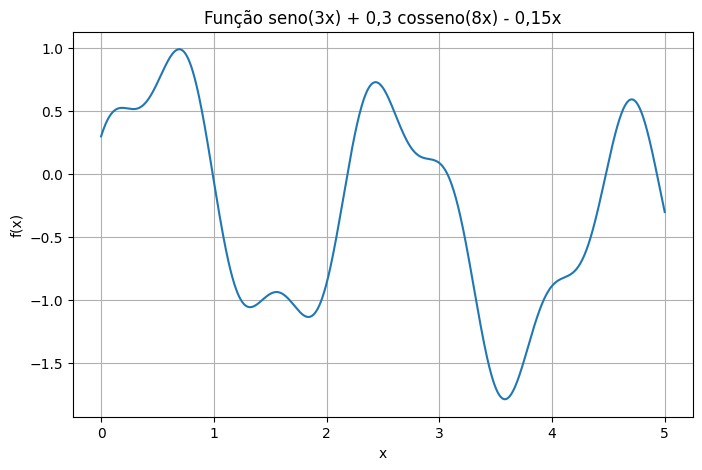

In [10]:
# Exemplo 1D com vários máximos e mínimos locais
def f_local_global(x):
    return np.sin(3*x) + 0.3*np.cos(8*x) - 0.15*x

x = np.linspace(0, 5, 800)
y = f_local_global(x)

plt.plot(x, y)
plt.title("Função seno(3x) + 0,3 cosseno(8x) - 0,15x")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


Observe que a curva acima pode apresentar vários picos e vales.  

Isso ajuda a entender por que, em PNL, um método numérico pode depender do ponto inicial e por que **concavidade** é tão importante.

**Quando a função é côncava em um problema de maximização irrestrito, qualquer máximo local já é global.**


# 4. Concavidade e Hessiana

Em várias situações, queremos verificar se uma determinada função é côncava ou convexa.

Para funções de duas variáveis, uma ferramenta muito útil é a **matriz Hessiana**.

Vejamos um exemplo para $f(x_1, x_2) = 2x_1x_2 + 2x_2 - x_1^2 - 2x_2^2$

In [11]:
# Exemplo: f(x1, x2) = 2x1x2 + 2x2 - x1^2 - 2x2^2
# Hessiana:
H = np.array([[-2,  2],
              [ 2, -4]])

print("Hessiana:")
print(H)

autovalores = np.linalg.eigvals(H)
print("\nAutovalores da Hessiana:")
print(autovalores)


Hessiana:
[[-2  2]
 [ 2 -4]]

Autovalores da Hessiana:
[-0.76393202 -5.23606798]


Se todos os autovalores da Hessiana forem **não positivos**, a função é côncava.  

Se todos forem **não negativos**, a função é convexa.

No exemplo acima, a Hessiana é negativa semidefinida/definida negativa, então a função é côncava.

# 5. Primeiro modelo de PNL no Pyomo

Vamos começar com um exemplo simples para revisar a sintaxe do Pyomo.

### Problema

$$max z = -3x^2 + y$$

sujeito a:

$$x^2 + y^2 \le 1$$

$$x \ge 0, \quad y \ge 0$$



In [ ]:
# Criando o modelo
M = pe.ConcreteModel()

# Variáveis
x = M.x = pe.Var(domain=pe.NonNegativeReals)
y = M.y = pe.Var(domain=pe.NonNegativeReals)

# Função objetivo
M.obj = pe.Objective(expr= -9*x**2 + 54*x - 13*y**2 + 78*y, sense=pe.maximize)

# Restrição não linear
M.c1 = pe.Constraint(expr= x <= 4)
M.c2 = pe.Constraint(expr= 2*y <= 12)
M.c3 = pe.Constraint(expr= 3*x + y <= 18)

# Resolvendo
resultado = resolver_modelo(M)

print(f"Valor ótimo da função objetivo: {valor(M.obj):.2f}")
print(f"x = {valor(x):.2f}")
print(f"y = {valor(y):.2f}")


Valor ótimo da função objetivo: 198.00
x = 3.00
y = 3.00


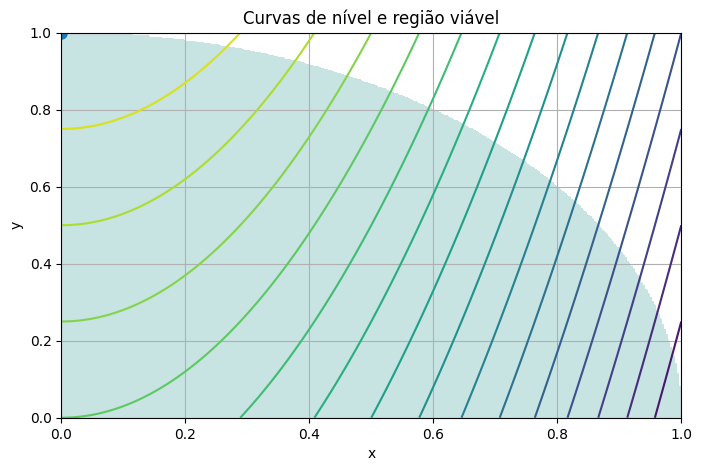

In [ ]:
# Visualização da região viável e da solução

xg = np.linspace(0, 1, 300)
yg = np.linspace(0, 1, 300)
X, Y = np.meshgrid(xg, yg)

Z = -3*X**2 + Y
mask = (X**2 + Y**2 <= 1)

plt.contour(X, Y, Z, levels=15)
plt.contourf(X, Y, mask, levels=[0.5, 1.5], alpha=0.25)
plt.plot(valor(x), valor(y), "o", markersize=8)
plt.title("Curvas de nível e região viável")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### Observação

Esse exemplo já ilustra uma ideia importante: em PNL, a solução ótima pode estar:
- no interior da região viável;
- na fronteira;
- ou até em um ponto onde a geometria não é tão intuitiva quanto em PL.


# 6. Problema irrestrito com uma variável

Considere o problema:

\[
\max f(x) = 12x - 3x^4 - 2x^6
\]

Vamos estudar esse problema de duas formas:
1. visualmente;
2. computacionalmente com Pyomo.


In [ ]:
def f1(x):
    return 12*x - 3*x**4 - 2*x**6

x = np.linspace(-2.0, 2.0, 1000)
plt.plot(x, f1(x))
plt.title("Problema irrestrito com uma variável")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


In [ ]:
M = pe.ConcreteModel()
M.x = pe.Var(initialize=1.0)
M.obj = pe.Objective(expr=12*M.x - 3*M.x**4 - 2*M.x**6, sense=pe.maximize)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x* =", valor(M.x))


In [ ]:
# Conferência analítica opcional com sympy
if SYMPY_AVAILABLE:
    x = sp.symbols('x', real=True)
    f = 12*x - 3*x**4 - 2*x**6
    df = sp.diff(f, x)
    d2f = sp.diff(df, x)
    print("f'(x) =", sp.expand(df))
    print("f''(x) =", sp.expand(d2f))
else:
    print("Sympy não está disponível neste ambiente.")


## Pergunta para discussão

A segunda derivada é sempre não positiva?  
Se sim, a função é côncava no domínio todo?  
Se não, o que isso implica para a interpretação do ponto encontrado?


# 7. Problema irrestrito com duas variáveis

Considere agora:

\[
\max f(x_1, x_2) = 2x_1x_2 + 2x_2 - x_1^2 - 2x_2^2
\]

Como a função é quadrática, podemos estudar a sua geometria por curvas de nível.


In [ ]:
def f2(x1, x2):
    return 2*x1*x2 + 2*x2 - x1**2 - 2*x2**2

x1 = np.linspace(-1, 3, 300)
x2 = np.linspace(-1, 3, 300)
X1, X2 = np.meshgrid(x1, x2)
Z = f2(X1, X2)

plt.contour(X1, X2, Z, levels=20)
plt.title("Curvas de nível do problema irrestrito com duas variáveis")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


In [ ]:
M = pe.ConcreteModel()
M.x = pe.Var([1, 2], initialize={1: 0.0, 2: 0.0})

M.obj = pe.Objective(
    expr=2*M.x[1]*M.x[2] + 2*M.x[2] - M.x[1]**2 - 2*M.x[2]**2,
    sense=pe.maximize
)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x1* =", valor(M.x[1]))
print("x2* =", valor(M.x[2]))


In [ ]:
plt.contour(X1, X2, Z, levels=20)
plt.plot(valor(M.x[1]), valor(M.x[2]), "o", markersize=8)
plt.title("Solução ótima do problema irrestrito com duas variáveis")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


### Interpretação

Neste caso, vale a pena discutir em sala:
- o ponto ótimo está no interior do espaço?
- por que não precisamos de restrições?
- como a curvatura da função ajuda a garantir a otimalidade global?


# 8. Problema de programação convexa

Considere o problema:

\[
\max f(x_1, x_2) = \ln(x_1 + 1) + x_2
\]

sujeito a:

\[
2x_1 + x_2 \le 3
\]
\[
x_1 \ge 0, \quad x_2 \ge 0
\]

A função objetivo é côncava e as restrições definem um conjunto convexo.  
Portanto, estamos em um **problema de programação convexa**.


In [ ]:
M = pe.ConcreteModel()
M.x = pe.Var([1, 2], domain=pe.NonNegativeReals, initialize={1: 0.5, 2: 1.0})

# Atenção: a restrição correta é 2*x1 + x2 <= 3
M.c1 = pe.Constraint(expr=2*M.x[1] + M.x[2] <= 3)

M.obj = pe.Objective(
    expr=pe.log(M.x[1] + 1) + M.x[2],
    sense=pe.maximize
)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x1* =", valor(M.x[1]))
print("x2* =", valor(M.x[2]))


In [ ]:
# Região viável e curvas de nível do problema convexo
x1 = np.linspace(0, 1.6, 300)
x2 = np.linspace(0, 3.2, 300)
X1, X2 = np.meshgrid(x1, x2)

Z = np.log(X1 + 1) + X2
mask = (2*X1 + X2 <= 3)

plt.contour(X1, X2, Z, levels=15)
plt.contourf(X1, X2, mask, levels=[0.5, 1.5], alpha=0.25)
plt.plot(valor(M.x[1]), valor(M.x[2]), "o", markersize=8)
plt.title("Problema convexo: região viável e solução ótima")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


## Leitura econômica/geométrica

Como se trata de maximização de uma função côncava em um conjunto convexo, qualquer solução que satisfaça as condições adequadas de otimalidade será globalmente ótima.

Esse é exatamente o tipo de problema em que a teoria ajuda muito:
- não basta encontrar um ponto bom;
- encontramos um ponto com garantia de otimalidade global.


# 9. Condições de KKT: interpretação prática

Para o problema anterior, a Lagrangiana pode ser escrita como:

\[
\mathcal{L}(x_1, x_2, u) = \ln(x_1+1) + x_2 + u(3 - 2x_1 - x_2)
\]

As condições de KKT ajudam a interpretar:
- viabilidade primal;
- viabilidade dual;
- estacionariedade;
- complementaridade.


### Para discutir em sala

Se a restrição \(2x_1 + x_2 \le 3\) estiver ativa no ótimo, então:
\[
u(3 - 2x_1 - x_2) = 0
\]
implica que o multiplicador pode ser positivo.

Já se a restrição não estiver ativa, o termo entre parênteses é estritamente positivo e, pela complementaridade, necessariamente \(u = 0\).

Essa leitura é extremamente útil porque conecta:
- geometria;
- sensibilidade;
- interpretação econômica dos multiplicadores.


In [ ]:
# Verificação numérica simples da restrição ativa
folga = 3 - (2*valor(M.x[1]) + valor(M.x[2]))
print("Folga da restrição 2x1 + x2 <= 3:", folga)


# 10. Problema de programação quadrática

Considere:

\[
\max f(x_1, x_2) = 15x_1 + 30x_2 + 4x_1x_2 - 2x_1^2 - 4x_2^2
\]

sujeito a:

\[
x_1 + 2x_2 \le 30
\]
\[
x_1 \ge 0, \quad x_2 \ge 0
\]

Esse é um exemplo clássico de **programação quadrática** com restrições lineares.


In [ ]:
M = pe.ConcreteModel()
M.x = pe.Var([1, 2], domain=pe.NonNegativeReals, initialize={1: 1.0, 2: 1.0})

M.c1 = pe.Constraint(expr=M.x[1] + 2*M.x[2] <= 30)

M.obj = pe.Objective(
    expr=15*M.x[1] + 30*M.x[2] + 4*M.x[1]*M.x[2] - 2*M.x[1]**2 - 4*M.x[2]**2,
    sense=pe.maximize
)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x1* =", valor(M.x[1]))
print("x2* =", valor(M.x[2]))


In [ ]:
x1 = np.linspace(0, 25, 300)
x2 = np.linspace(0, 16, 300)
X1, X2 = np.meshgrid(x1, x2)

Z = 15*X1 + 30*X2 + 4*X1*X2 - 2*X1**2 - 4*X2**2
mask = (X1 + 2*X2 <= 30)

plt.contour(X1, X2, Z, levels=20)
plt.contourf(X1, X2, mask, levels=[0.5, 1.5], alpha=0.25)
plt.plot(valor(M.x[1]), valor(M.x[2]), "o", markersize=8)
plt.title("Programação quadrática: região viável e solução ótima")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


# 11. Exercício guiado 1

Resolva o problema abaixo no Pyomo e interprete o resultado:

\[
\max f(x_1, x_2) = 5x_1 - x_1^2 + 8x_2 - 2x_2^2
\]

sujeito a:

\[
3x_1 + 2x_2 \le 6
\]
\[
x_1 \ge 0, \quad x_2 \ge 0
\]

## Perguntas
1. A solução ótima está na fronteira ou no interior da região viável?  
2. A função objetivo é côncava?  
3. Podemos garantir que o ótimo encontrado é global?


In [ ]:
# Exercício guiado 1 — complete a modelagem

M = pe.ConcreteModel()

# Variáveis
M.x = pe.Var([1, 2], domain=pe.NonNegativeReals)

# Restrição
M.c1 = pe.Constraint(expr=3*M.x[1] + 2*M.x[2] <= 6)

# Função objetivo
M.obj = pe.Objective(
    expr=5*M.x[1] - M.x[1]**2 + 8*M.x[2] - 2*M.x[2]**2,
    sense=pe.maximize
)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x1* =", valor(M.x[1]))
print("x2* =", valor(M.x[2]))
print("Folga =", 6 - (3*valor(M.x[1]) + 2*valor(M.x[2])))


## Comentário

Depois de resolver, verifique se a Hessiana da função objetivo é negativa semidefinida/definida negativa.  
Isso ajuda a justificar teoricamente a resposta.


# 12. Exercício guiado 2

Resolva o problema:

\[
\max f(x_1, x_2) = 24x_1 - x_1^2 + 10x_2 - x_2^2
\]

sujeito a:

\[
x_1 \le 10
\]
\[
x_2 \le 15
\]
\[
x_1 \ge 0, \quad x_2 \ge 0
\]

## Perguntas
1. O ótimo irrestrito já é viável?  
2. Quais restrições ficam ativas no ótimo?  
3. Como esse problema se compara a um problema de PL?


In [ ]:
# Exercício guiado 2 — complete a modelagem

M = pe.ConcreteModel()

M.x = pe.Var([1, 2], domain=pe.NonNegativeReals)

M.c1 = pe.Constraint(expr=M.x[1] <= 10)
M.c2 = pe.Constraint(expr=M.x[2] <= 15)

M.obj = pe.Objective(
    expr=24*M.x[1] - M.x[1]**2 + 10*M.x[2] - M.x[2]**2,
    sense=pe.maximize
)

resultado = resolver_modelo(M)

print("f(x*) =", valor(M.obj))
print("x1* =", valor(M.x[1]))
print("x2* =", valor(M.x[2]))


# 13. Desafio final

Escolha **um** dos problemas resolvidos neste notebook e faça uma extensão. Algumas sugestões:

- trocar a função objetivo por outra não linear;
- incluir mais uma restrição;
- alterar o ponto inicial e observar o comportamento do solver;
- discutir se o problema continua convexo ou não convexo.

O mais importante é justificar:
1. a modelagem;
2. a interpretação da solução;
3. se há ou não garantia de otimalidade global.


# 14. Fechamento

Neste notebook, vimos que um bom estudo de PNL combina três camadas:

1. **intuição geométrica**  
2. **análise matemática**  
3. **implementação computacional**

Esse encadeamento costuma funcionar muito bem em sala:
- primeiro o aluno enxerga;
- depois ele interpreta;
- por fim, ele implementa.

Se quiser, na próxima etapa você pode complementar este material com:
- um bloco extra sobre **KKT resolvido passo a passo**;
- um bloco sobre **dependência do ponto inicial em problemas não convexos**;
- ou uma lista curta de exercícios adicionais.
